## Week 1 task

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [160]:
df.info()
df.shape
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


np.int64(0)

## WEEK 2 – DATA CLEANING

In [161]:
df.info()
df.isnull().sum()
(df.isnull().sum()/len(df))*100
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


np.int64(0)

In [162]:
df['type'].unique()
df['rating'].unique()
df['country'].unique()
df['type'].value_counts()
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [163]:
df[df['rating'].str.contains('min', na=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [164]:
mask = df['rating'].str.contains('min', na=False)

df.loc[mask, 'duration'] = df.loc[mask, 'rating']
df.loc[mask, 'rating'] = None

In [165]:
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [166]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

In [167]:
df['director'] = df['director'].fillna('Unknown')

In [168]:
df['cast'] = df['cast'].fillna('Unknown')

In [169]:
df['country'] = df['country'].fillna('Not Available')

In [170]:
df['rating'] = df['rating'].fillna("Not Rated")

In [171]:
df.dropna(subset=['date_added'], inplace=True)

In [172]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

## Week-3: Normalization of Categorical Features

In [173]:
df['type'].unique()
df['rating'].unique()
df['country'].head()

0    United States
1     South Africa
2    Not Available
3    Not Available
4            India
Name: country, dtype: object

In [174]:
df['type'].value_counts()
df['rating'].value_counts()

rating
TV-MA        3205
TV-14        2157
TV-PG         861
R             799
PG-13         490
TV-Y7         333
TV-Y          306
PG            287
TV-G          220
NR             79
G              41
Not Rated       7
TV-Y7-FV        6
NC-17           3
UR              3
Name: count, dtype: int64

In [175]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

In [176]:
df['type'] = df['type'].str.title()
df['rating'] = df['rating'].str.upper()
df['country'] = df['country'].str.title()

In [177]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [178]:
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_type'] = df['duration'].str.extract('([A-Za-z]+)')

In [179]:
df['listed_in'] = df['listed_in'].apply(lambda x: [i.strip() for i in x.split(',')])

In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8797 non-null   object        
 1   type           8797 non-null   object        
 2   title          8797 non-null   object        
 3   director       8797 non-null   object        
 4   cast           8797 non-null   object        
 5   country        8797 non-null   object        
 6   date_added     8797 non-null   datetime64[ns]
 7   release_year   8797 non-null   int64         
 8   rating         8797 non-null   object        
 9   duration       8797 non-null   object        
 10  listed_in      8797 non-null   object        
 11  description    8797 non-null   object        
 12  duration_num   8797 non-null   float64       
 13  duration_type  8797 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(11)
memory usage: 1.0+ MB


In [181]:
df.reset_index(drop=True, inplace=True)

In [182]:
df['listed_in'] = df['listed_in'].apply(
    lambda x: [i.strip() for i in x.split(',')] if isinstance(x, str) else x
)

In [183]:
df['release_year'].describe()
df['duration_num'].describe()

count    8797.000000
mean       69.921792
std        50.788599
min         1.000000
25%         2.000000
50%        88.000000
75%       106.000000
max       312.000000
Name: duration_num, dtype: float64

In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8797 non-null   object        
 1   type           8797 non-null   object        
 2   title          8797 non-null   object        
 3   director       8797 non-null   object        
 4   cast           8797 non-null   object        
 5   country        8797 non-null   object        
 6   date_added     8797 non-null   datetime64[ns]
 7   release_year   8797 non-null   int64         
 8   rating         8797 non-null   object        
 9   duration       8797 non-null   object        
 10  listed_in      8797 non-null   object        
 11  description    8797 non-null   object        
 12  duration_num   8797 non-null   float64       
 13  duration_type  8797 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(11)
memory usage: 962

In [185]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [186]:
df['year_added'] = df['year_added'].astype(int)
df['month_added'] = df['month_added'].astype(int)

In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8797 non-null   object        
 1   type           8797 non-null   object        
 2   title          8797 non-null   object        
 3   director       8797 non-null   object        
 4   cast           8797 non-null   object        
 5   country        8797 non-null   object        
 6   date_added     8797 non-null   datetime64[ns]
 7   release_year   8797 non-null   int64         
 8   rating         8797 non-null   object        
 9   duration       8797 non-null   object        
 10  listed_in      8797 non-null   object        
 11  description    8797 non-null   object        
 12  duration_num   8797 non-null   float64       
 13  duration_type  8797 non-null   object        
 14  year_added     8797 non-null   int64         
 15  month_added    8797 n

In [188]:
original = pd.read_csv("netflix_titles.csv", usecols=['listed_in'])

In [189]:
df['listed_in'] = original['listed_in']

In [190]:
df['listed_in'].head()

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
Name: listed_in, dtype: object

In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8797 non-null   object        
 1   type           8797 non-null   object        
 2   title          8797 non-null   object        
 3   director       8797 non-null   object        
 4   cast           8797 non-null   object        
 5   country        8797 non-null   object        
 6   date_added     8797 non-null   datetime64[ns]
 7   release_year   8797 non-null   int64         
 8   rating         8797 non-null   object        
 9   duration       8797 non-null   object        
 10  listed_in      8797 non-null   object        
 11  description    8797 non-null   object        
 12  duration_num   8797 non-null   float64       
 13  duration_type  8797 non-null   object        
 14  year_added     8797 non-null   int64         
 15  month_added    8797 n

In [192]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

In [193]:
df['type'] = df['type'].str.title()
df['country'] = df['country'].str.title()
df['rating'] = df['rating'].str.upper()

In [194]:
df[['duration','duration_num','duration_type']].head()

,duration,duration_num,duration_type
0,90 min,90.0,min
1,2 Seasons,2.0,Seasons
2,1 Season,1.0,Season
3,1 Season,1.0,Season
4,2 Seasons,2.0,Seasons


In [195]:
df.duplicated().sum()

np.int64(0)

In [196]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8797 non-null   object        
 1   type           8797 non-null   object        
 2   title          8797 non-null   object        
 3   director       8797 non-null   object        
 4   cast           8797 non-null   object        
 5   country        8797 non-null   object        
 6   date_added     8797 non-null   datetime64[ns]
 7   release_year   8797 non-null   int64         
 8   rating         8797 non-null   object        
 9   duration       8797 non-null   object        
 10  listed_in      8797 non-null   object        
 11  description    8797 non-null   object        
 12  duration_num   8797 non-null   float64       
 13  duration_type  8797 non-null   object        
 14  year_added     8797 non-null   int64         
 15  month_added    8797 n

## Week-4

In [197]:
content_per_year = df['year_added'].value_counts().sort_index()

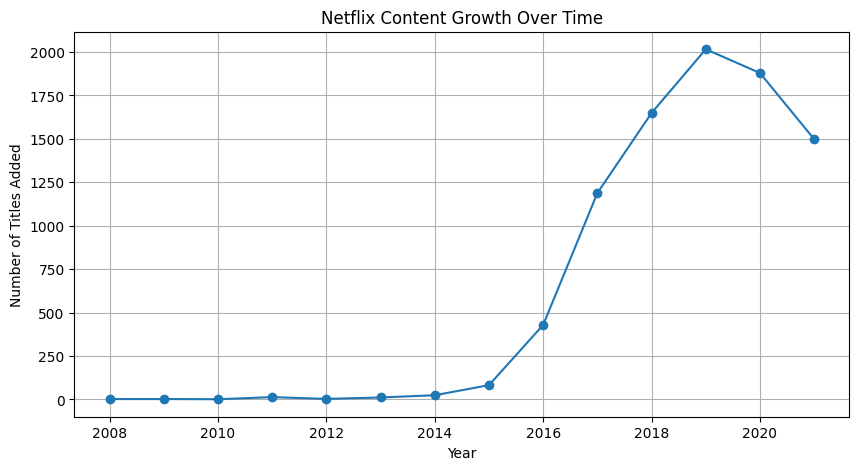

In [198]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(content_per_year.index, content_per_year.values, marker='o')

plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.grid(True)
plt.show()

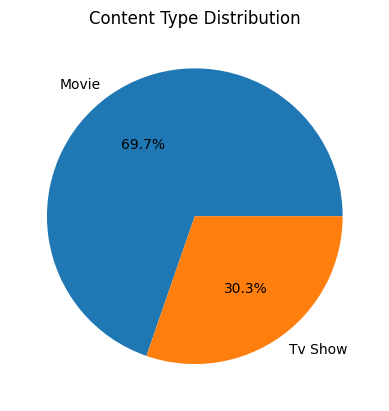

In [199]:
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Content Type Distribution")
plt.ylabel("")

plt.show()

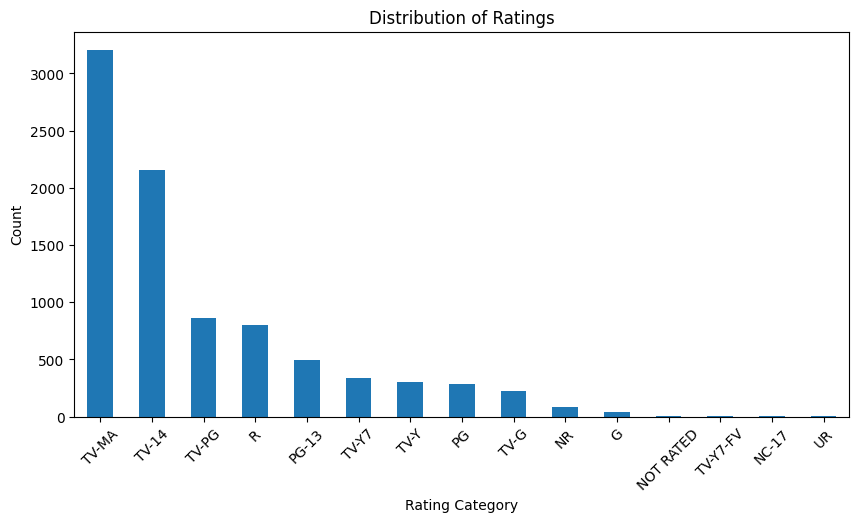

In [200]:
df['rating'].value_counts().plot(kind='bar', figsize=(10,5))

plt.title("Distribution of Ratings")
plt.xlabel("Rating Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [201]:
country_counts = df[df['country'] != 'Not Available']['country'].value_counts().head(10)
country_counts

country
United States     2812
India              972
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

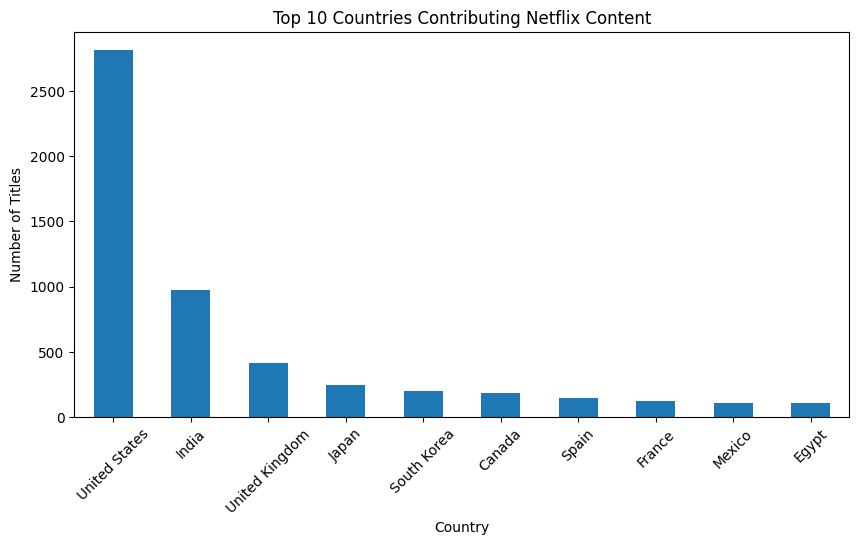

In [202]:
import matplotlib.pyplot as plt

country_counts.plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Countries Contributing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)
plt.show()

In [203]:
def length_category(x):
    if x < 60:
        return "Short"
    elif x <= 120:
        return "Medium"
    else:
        return "Long"

df['content_length_category'] = df['duration_num'].apply(length_category)

In [204]:
df['content_length_category'].value_counts()

content_length_category
Medium    4531
Short     3124
Long      1142
Name: count, dtype: int64

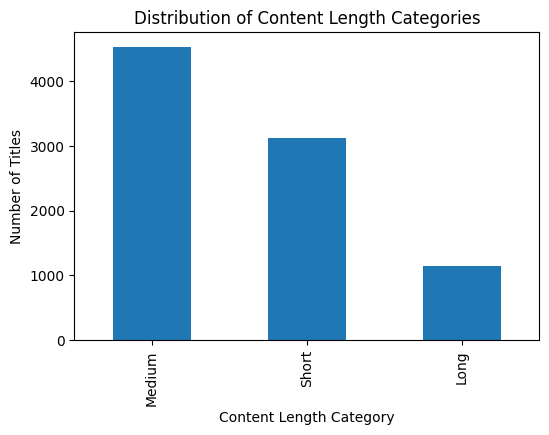

In [205]:
import matplotlib.pyplot as plt

df['content_length_category'].value_counts().plot(kind='bar', figsize=(6,4))

plt.title("Distribution of Content Length Categories")
plt.xlabel("Content Length Category")
plt.ylabel("Number of Titles")

plt.show()

In [206]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['added_year'] = df['date_added'].dt.year

In [207]:
df['content_origin'] = df.apply(
    lambda x: 'Netflix Original' if x['added_year'] == x['release_year'] else 'Licensed',
    axis=1
)

In [208]:
origin_dist = df['content_origin'].value_counts().reset_index()
origin_dist.columns = ['origin','count']

print(origin_dist)

             origin  count
0          Licensed   5556
1  Netflix Original   3241


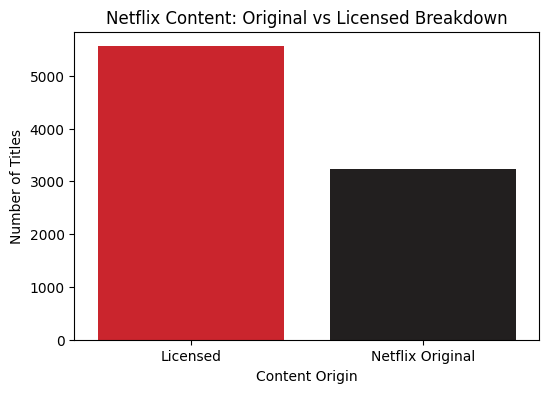

In [209]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.barplot(
    data=origin_dist,
    x='origin',
    y='count',
    hue='origin',
    palette=['#E50914','#221F1F'],
    legend=False
)

plt.title("Netflix Content: Original vs Licensed Breakdown")
plt.xlabel("Content Origin")
plt.ylabel("Number of Titles")

plt.show()

In [210]:
genres = df['listed_in'].str.split(', ').explode()

In [211]:
top_genres = genres.value_counts().head(10)

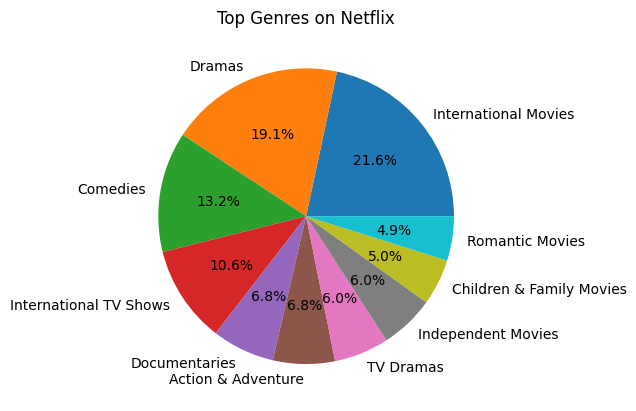

In [212]:
top_genres.plot(kind='pie', autopct='%1.1f%%')

plt.title("Top Genres on Netflix")
plt.ylabel("")

plt.show()

## Week-5

Clustering Netflix Titles

In [213]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans

In [214]:
## Encode Rating
le_rating = LabelEncoder()
df['rating_encoded'] = le_rating.fit_transform(df['rating'])

In [215]:
## Encode Genre
le_genre = LabelEncoder()
df['genre_encoded'] = le_genre.fit_transform(df['listed_in'])

In [216]:
## Encode Content Type
le_type = LabelEncoder()
df['type_encoded'] = le_type.fit_transform(df['type'])

In [217]:
X = df[['duration_num','genre_encoded','rating_encoded','type_encoded']]

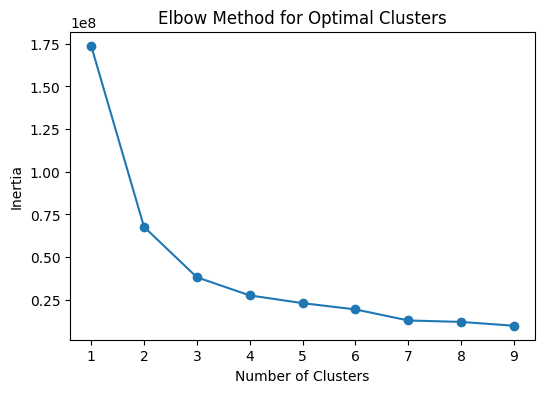

In [218]:
inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,10), inertia, marker='o')

plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

In [219]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['cluster'] = kmeans.fit_predict(X)

In [220]:
cluster_map = {0:'Cluster A',1:'Cluster B',2:'Cluster C'}

df['cluster_label'] = df['cluster'].map(cluster_map)

In [221]:
df['cluster_label'].value_counts()

cluster_label
Cluster C    4597
Cluster B    2194
Cluster A    2006
Name: count, dtype: int64

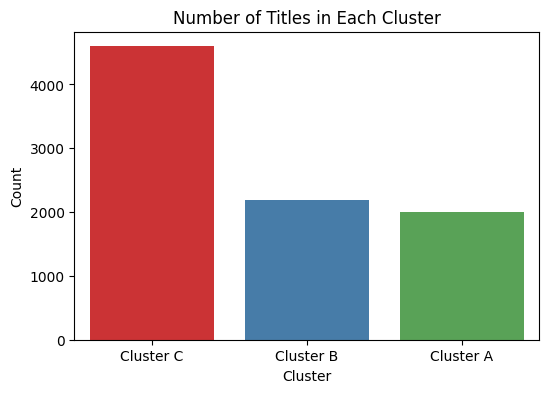

In [222]:
plt.figure(figsize=(6,4))

sns.countplot(x='cluster_label', hue='cluster_label', data=df, palette='Set1', legend=False)

plt.title("Number of Titles in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")

plt.show()

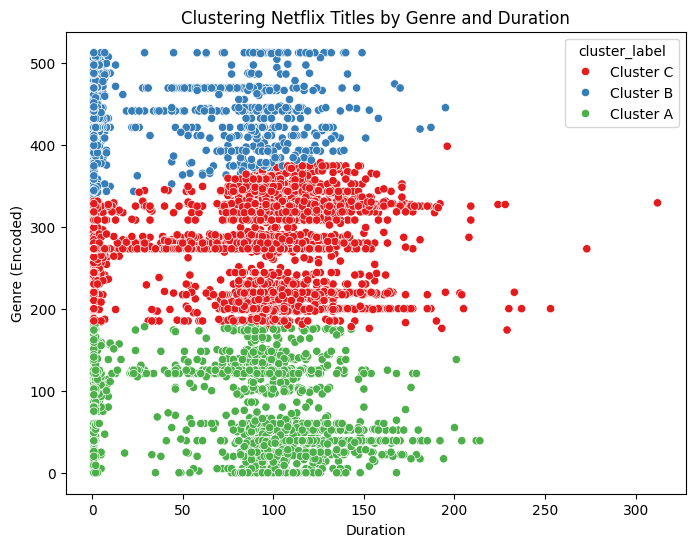

In [223]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='duration_num',
    y='genre_encoded',
    hue='cluster_label',
    data=df,
    palette='Set1'
)

plt.title("Clustering Netflix Titles by Genre and Duration")
plt.xlabel("Duration")
plt.ylabel("Genre (Encoded)")

plt.show()

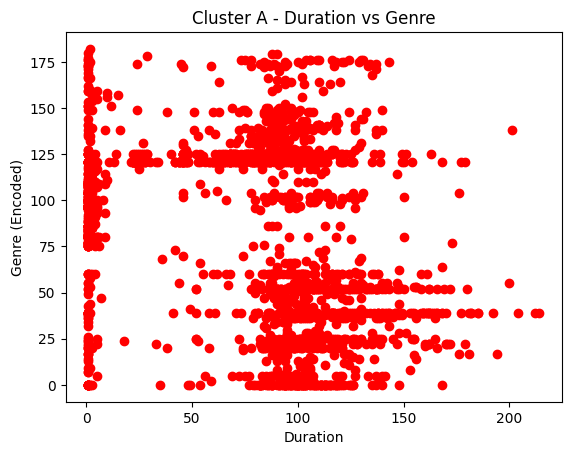

In [224]:
clusterA = df[df['cluster_label']=='Cluster A']

plt.scatter(clusterA['duration_num'], clusterA['genre_encoded'], color='red')

plt.title("Cluster A - Duration vs Genre")
plt.xlabel("Duration")
plt.ylabel("Genre (Encoded)")

plt.show()

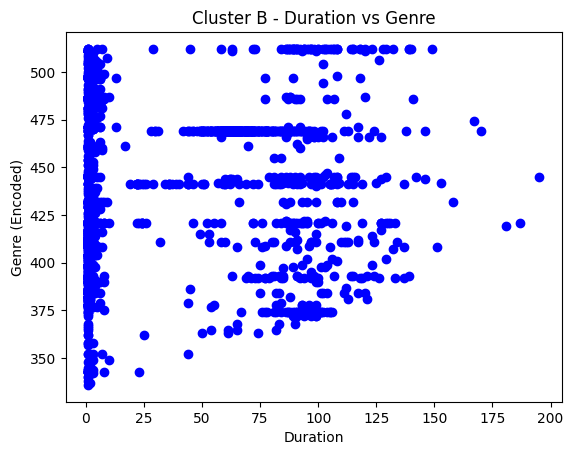

In [225]:
clusterB = df[df['cluster_label']=='Cluster B']

plt.scatter(clusterB['duration_num'], clusterB['genre_encoded'], color='blue')

plt.title("Cluster B - Duration vs Genre")
plt.xlabel("Duration")
plt.ylabel("Genre (Encoded)")

plt.show()

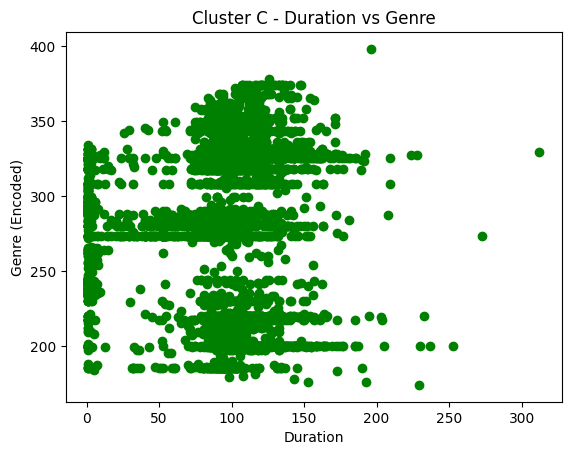

In [226]:
clusterC = df[df['cluster_label']=='Cluster C']

plt.scatter(clusterC['duration_num'], clusterC['genre_encoded'], color='green')

plt.title("Cluster C - Duration vs Genre")
plt.xlabel("Duration")
plt.ylabel("Genre (Encoded)")

plt.show()

In [232]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [233]:
X = df[['duration_num','year_added','month_added','rating_encoded']]
y = df['type_encoded']

In [235]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [237]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [240]:
y_pred = model.predict(X_test)

In [242]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1226    3]
 [   0  531]]


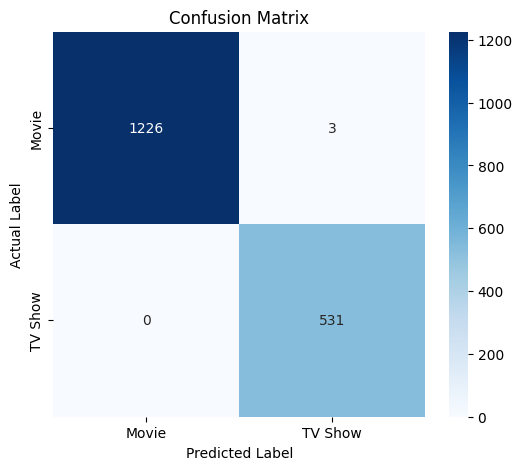

In [243]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Movie','TV Show'],
    yticklabels=['Movie','TV Show']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## WEEK-6

In [245]:
country_genre = df.groupby(['country','listed_in']).size().reset_index(name='count')

top_country_genre = country_genre.sort_values('count', ascending=False).head(10)

print(top_country_genre)

            country                                         listed_in  count
2667  United States                                     Documentaries    206
2812  United States                                   Stand-Up Comedy    201
934           India            Comedies, Dramas, International Movies    106
2775  United States                                          Kids' TV     90
979           India                      Dramas, International Movies     84
2553  United States                Children & Family Movies, Comedies     83
974           India  Dramas, Independent Movies, International Movies     82
2598  United States                                          Comedies     74
2694  United States                                            Dramas     70
1224          Japan              Anime Series, International TV Shows     70


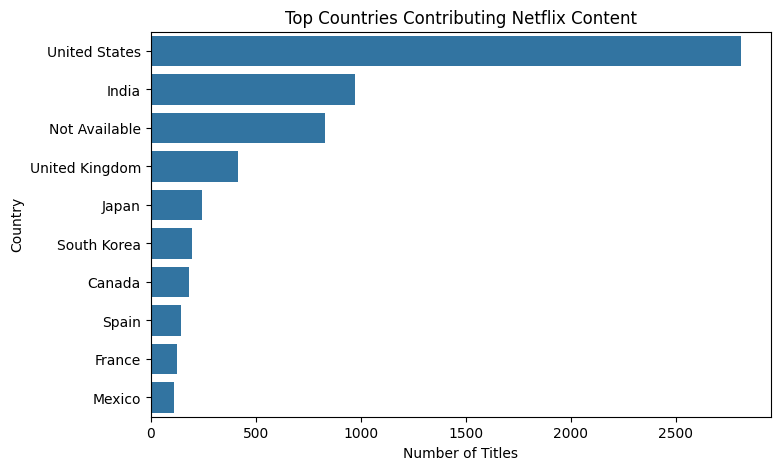

In [248]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top Countries Contributing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

In [250]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

          Feature  Importance
3  rating_encoded    0.177674
1      year_added    0.004727
2     month_added   -0.239055
0    duration_num   -0.752719


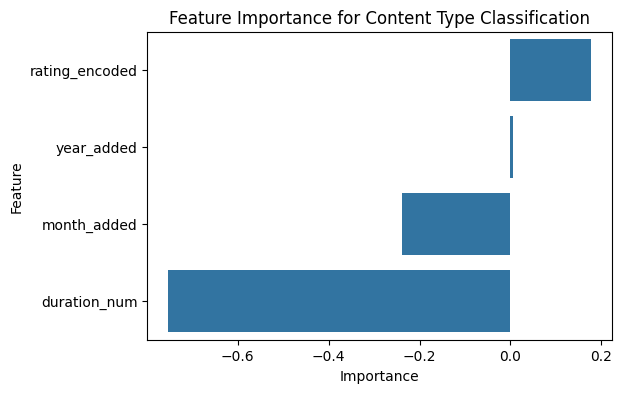

In [252]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance for Content Type Classification")

plt.show()